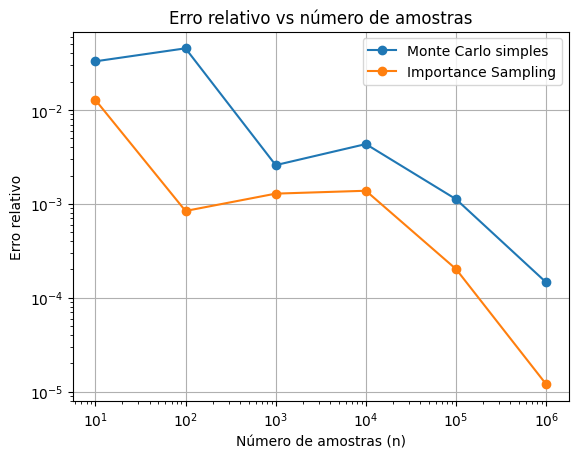

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# valor "exato" (aproximação numérica fina)
from scipy.integrate import quad
I, _ = quad(lambda x: np.exp(-x**2), 0, 1)

# Monte Carlo simples
def monte_carlo_simples(n):
    X = np.random.uniform(0, 1, n)
    return np.mean(np.exp(-X**2))

# Importance Sampling
def importance_sampling(n):
    U = np.random.uniform(0, 1, n)
    X = -np.log(1 - U * (1 - np.exp(-1)))
    A = 1 / (1 - np.exp(-1))
    return np.mean(np.exp(-X**2) / (A * np.exp(-X)))

# valores de n
ns = [10**k for k in range(1, 7)]

erro_mc = []
erro_is = []

# rodar experimentos
for n in ns:
    mc = monte_carlo_simples(n)
    is_ = importance_sampling(n)
    
    erro_mc.append(abs(mc - I) / I)
    erro_is.append(abs(is_ - I) / I)

# plot
plt.figure()
plt.xscale('log')
plt.yscale('log')

plt.plot(ns, erro_mc, marker='o', label='Monte Carlo simples')
plt.plot(ns, erro_is, marker='o', label='Importance Sampling')

plt.xlabel('Número de amostras (n)')
plt.ylabel('Erro relativo')
plt.title('Erro relativo vs número de amostras')

plt.legend()
plt.grid()

plt.show()